### t1

In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import odeint
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [421]:
# 炉子参数
ZONE_LENGTH = 30.5  # cm，小温区长度
GAP_LENGTH = 5      # cm，间隙长度
FRONT_LENGTH = 25   # cm，炉前区域长度
BACK_LENGTH = 25    # cm，炉后区域长度
AMBIENT_TEMP = 25   # °C，环境温度
THICKNESS = 0.15    # mm，焊接区域厚度

# 全局变量存储实验数据和拟合参数
exp_time = None
exp_temp = None
heat_transfer_coeff = None

print("炉温曲线仿真参数已设置")
print(f"小温区长度：{ZONE_LENGTH} cm")
print(f"间隙长度：{GAP_LENGTH} cm")
print(f"炉前区域长度：{FRONT_LENGTH} cm")
print(f"环境温度：{AMBIENT_TEMP} °C")

炉温曲线仿真参数已设置
小温区长度：30.5 cm
间隙长度：5 cm
炉前区域长度：25 cm
环境温度：25 °C


In [422]:
def load_experimental_data(file_path):
    """读取实验数据"""
    global exp_time, exp_temp
    
    try:
        # 尝试读取Excel文件
        df = pd.read_excel(file_path)

        time_col = df.columns[0]
        temp_col = df.columns[1]
        
        exp_time = df[time_col].values
        exp_temp = df[temp_col].values
        
        
        print(f"成功读取实验数据：{len(exp_time)}个数据点")
        return True
    except Exception as e:
        print(f"读取实验数据失败：{e}")
        return False

load_experimental_data("fujian.xlsx")
# exp_temp


成功读取实验数据：709个数据点


True

In [423]:
def calculate_position(time, speed):
    """根据时间和速度计算位置"""
    return speed * time / 60  # 转换为cm/s

In [424]:
def get_zone_temp(position, zone_temps):
    """根据位置获取对应温区的设定温度"""
    # 炉前区域
    if position < FRONT_LENGTH*0.8:#: #* 
        return AMBIENT_TEMP
    if position < FRONT_LENGTH:
        # 线性升温：从25°C到第一个温区温度
        temp_ratio = position / (FRONT_LENGTH*0.2)
        return AMBIENT_TEMP + (40 - AMBIENT_TEMP) * temp_ratio
    
    # 计算在哪个温区
    pos_in_oven = position - FRONT_LENGTH
    
    # 11个小温区
    for i in range(11):
        zone_start = i * (ZONE_LENGTH + GAP_LENGTH)
        zone_end = zone_start + ZONE_LENGTH
        
        if zone_start <= pos_in_oven < zone_end:
            # 在温区内
            if i < 5:  # 小温区1-5
                return zone_temps[0]
            elif i == 5:  # 小温区6
                return zone_temps[1]
            elif i == 6:  # 小温区7
                return zone_temps[2]
            elif i in [7, 8]:  # 小温区8-9
                return zone_temps[3]
            elif i == 9:  # 小温区10
                pos = pos_in_oven - zone_start + GAP_LENGTH  #距离温区9的距离
                # 小温区10的温度是一个线性函数，由环境温度和小温区10的温度决定
                temp_ratio = pos / (2*(ZONE_LENGTH + GAP_LENGTH))  # 位置在小温区10的比例 (0-1)

                return zone_temps[3] - (zone_temps[3] - AMBIENT_TEMP) * temp_ratio
            else:  # 小温区11
                pos = pos_in_oven - zone_start + GAP_LENGTH  #距离温区9的距离
                # 小温区10的温度是一个线性函数，由环境温度和小温区10的温度决定
                temp_ratio = (pos + ZONE_LENGTH + GAP_LENGTH) / (2*(ZONE_LENGTH + GAP_LENGTH))  # 位置在小温区10的比例 (0-1)
                return zone_temps[3] - (zone_temps[3] - AMBIENT_TEMP) * temp_ratio
                
        elif zone_end <= pos_in_oven < zone_end + GAP_LENGTH:
            # 在间隙中，温度应该是一个线性函数，由两侧温区决定的线性函数
            gap_position = pos_in_oven - zone_end  # 在间隙中的位置
            gap_ratio = gap_position / GAP_LENGTH   # 间隙中的相对位置 (0-1)
            
            if i < 4:
                # 前4个间隙都在第一个温区内
                return zone_temps[0]
            elif i == 4:
                # 第5个间隙：在温区1和温区6之间线性插值
                temp_start = zone_temps[0]
                temp_end = zone_temps[1]
                return temp_start + (temp_end - temp_start) * gap_ratio
            elif i == 5:
                # 第6个间隙：在温区6和温区7之间线性插值
                temp_start = zone_temps[1]
                temp_end = zone_temps[2]
                return temp_start + (temp_end - temp_start) * gap_ratio
            elif i == 6:
                # 第7个间隙：在温区7和温区8-9之间线性插值
                temp_start = zone_temps[2]
                temp_end = zone_temps[3]
                return temp_start + (temp_end - temp_start) * gap_ratio
            elif i == 7:
                # 第8个间隙：在温区8-9内
                return zone_temps[3]
            elif i == 8:

                # 第9个间隙：在温区8-9和环境温度之间线性插值
                temp_start = zone_temps[3]
                temp_end = AMBIENT_TEMP

                # 小温区10的温度是一个线性函数，由环境温度和小温区10的温度决定
                _gap_ratio = gap_position / (2 * (ZONE_LENGTH + GAP_LENGTH))
                return temp_start + (temp_end - temp_start) * _gap_ratio
            elif i == 9:
                # 第10个间隙：在温区10-11之间线性插值
                temp_start = zone_temps[3]
                temp_end = AMBIENT_TEMP
                _gap_ratio = (gap_position + ZONE_LENGTH + GAP_LENGTH) / (2 * (ZONE_LENGTH + GAP_LENGTH))

                return temp_start + (temp_end - temp_start) * _gap_ratio
            else:

                return AMBIENT_TEMP
    
    # 炉后区域
    return AMBIENT_TEMP


In [425]:
import numpy as np
from scipy import ndimage
from scipy.interpolate import interp1d
def gaussian_smooth_zone_temp(position_array, zone_temps, sigma=2.0):
    """
    对温区温度函数进行高斯核平滑
    
    参数:
    position_array: 位置数组
    zone_temps: 温区温度设置
    sigma: 高斯核标准差，控制平滑程度
    
    返回:
    平滑后的温度数组
    """
    # 首先计算原始的分段函数值
    original_temps = []
    for pos in position_array:
        temp = get_zone_temp(pos, zone_temps)
        original_temps.append(temp)
    
    original_temps = np.array(original_temps)
    
    # 使用高斯滤波进行平滑
    smoothed_temps = ndimage.gaussian_filter1d(original_temps, sigma=sigma)
    
    return smoothed_temps

def get_zone_temp_smooth(position, zone_temps, sigma=3.0):
    """
    获取平滑后的温区温度（单点查询版本）
    
    参数:
    position: 查询位置
    zone_temps: 温区温度设置
    sigma: 高斯核标准差
    
    返回:
    平滑后的温度值
    """
    # 创建位置数组用于平滑计算
    total_length = FRONT_LENGTH + 11 * (ZONE_LENGTH + GAP_LENGTH) + 50  # 总长度
    pos_array = np.linspace(0, total_length, 1000)  # 高分辨率位置数组
    
    # 计算平滑后的温度数组
    smooth_temps = gaussian_smooth_zone_temp(pos_array, zone_temps, sigma)
    
    # 使用插值获取指定位置的温度
    interp_func = interp1d(pos_array, smooth_temps, kind='linear', 
                          bounds_error=False, fill_value='extrapolate')
    
    return float(interp_func(position))

In [426]:

# def get_zone_temp(position, zone_temps):
#     """根据位置获取对应温区的设定温度"""
#     # 炉前区域
#     if position < FRONT_LENGTH:
#         return AMBIENT_TEMP
    
#     # 计算在哪个温区
#     pos_in_oven = position - FRONT_LENGTH
    
#     # 定义各温区中心位置和对应温度
#     zone_centers = []
#     zone_center_temps = []
    
#     # 计算各温区中心位置
#     for i in range(11):
#         zone_start = i * (ZONE_LENGTH + GAP_LENGTH)
#         zone_center = zone_start + ZONE_LENGTH / 2  # 温区中心位置
#         zone_centers.append(zone_center)
        
#         # 确定温区中心温度
#         if i < 5:  # 小温区1-5
#             zone_center_temps.append(zone_temps[0])
#         elif i == 5:  # 小温区6
#             zone_center_temps.append(zone_temps[1])
#         elif i == 6:  # 小温区7
#             zone_center_temps.append(zone_temps[2])
#         elif i in [7, 8]:  # 小温区8-9
#             zone_center_temps.append(zone_temps[3])
#         else:  # 小温区10-11
#             zone_center_temps.append(AMBIENT_TEMP)
    
#     # 添加炉前和炉后的虚拟中心点
#     all_positions = [0] + zone_centers + [11 * (ZONE_LENGTH + GAP_LENGTH)]
#     all_temps = [AMBIENT_TEMP] + zone_center_temps + [AMBIENT_TEMP]
    
#     # 使用线性插值计算当前位置的温度
#     if pos_in_oven <= 0:
#         return AMBIENT_TEMP
#     elif pos_in_oven >= all_positions[-1]:
#         return AMBIENT_TEMP
#     else:
#         # 找到当前位置在哪两个中心点之间
#         for i in range(len(all_positions) - 1):
#             if all_positions[i] <= pos_in_oven <= all_positions[i + 1]:
#                 # 线性插值
#                 pos_ratio = (pos_in_oven - all_positions[i]) / (all_positions[i + 1] - all_positions[i])
#                 temp = all_temps[i] + (all_temps[i + 1] - all_temps[i]) * pos_ratio
#                 return temp
    
#     return AMBIENT_TEMP

In [ ]:
def temperature_ode(T, t, speed, zone_temps):
    """温度变化的微分方程"""
    position = calculate_position(t, speed)
    T_zone = get_zone_temp_smooth(position, zone_temps)
    
    # 简化的传热模型：dT/dt = h * (T_zone - T)
    global heat_transfer_coeff

    h_eff = heat_transfer_coeff
    
    dTdt = h_eff * (T_zone - T)
    return dTdt

In [428]:
def fit_parameters():
    """通过实验数据拟合模型参数"""
    global heat_transfer_coeff, exp_time, exp_temp
    
    if exp_time is None or exp_temp is None:
        print("请先加载实验数据")
        return False
    
    # 实验条件
    exp_speed = 70  # cm/min
    exp_zone_temps = [175, 195, 235, 255]  # °C
    
    def model_temp(t, h_eff):
        """模型温度计算函数"""
        T0 = 25  # 初始温度
        try:
            T = odeint(lambda T, t: h_eff * (get_zone_temp(
                calculate_position(t, exp_speed), exp_zone_temps) - T), 
                T0, t)
            return T.flatten()
        except:
            return np.full_like(t, T0)
    
    try:
        # 拟合传热系数
        popt, _ = curve_fit(model_temp, exp_time, exp_temp, 
                          bounds=(0.01, 1.0), maxfev=100000)
        heat_transfer_coeff = popt[0]
        print(f"拟合得到的传热系数：{heat_transfer_coeff:.14f}")
        return True
    except Exception as e:
        print(f"参数拟合失败：{e}")
        # 使用默认值
        heat_transfer_coeff = 0.1
        return False

fit_parameters()


拟合得到的传热系数：0.01800671198724


True

In [429]:
def simulate_temperature(speed, zone_temps, time_step=0.1, max_time=300):
    """仿真温度变化"""
    # 时间数组
    # #heat_transfer_coeff = 0.0177
    time_array = np.arange(0, max_time, time_step)
    
    # 初始温度
    T0 = 25  # °C
    
    # 求解微分方程
    try:
        temperature = odeint(temperature_ode, T0, time_array, 
                           args=(speed, zone_temps))
        temperature = temperature.flatten()
    except Exception as e:
        print(f"温度仿真失败：{e}")
        return None, None
    
    return time_array, temperature

time, fit_tmp = simulate_temperature(70, [175, 195, 235, 255], 0.5, 400)


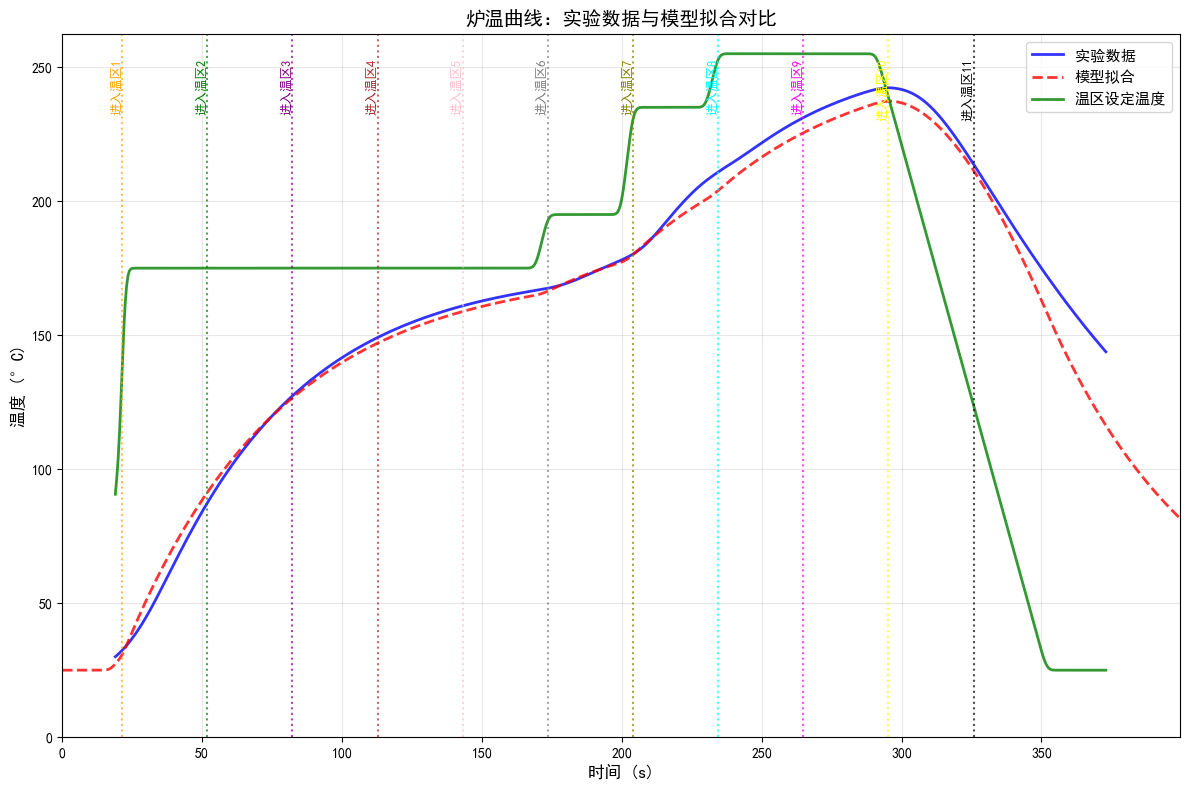

实验数据点数：709
仿真数据点数：800
实验温度范围：30.0°C - 242.3°C
仿真温度范围：25.0°C - 237.3°C


In [430]:
# 绘制实验数据与拟合数据的对比图
plt.figure(figsize=(12, 8))

# 绘制实验数据
plt.plot(exp_time, exp_temp, 'b-', linewidth=2, label='实验数据', alpha=0.8)

# 绘制拟合数据
if time is not None and fit_tmp is not None:
    plt.plot(time, fit_tmp, 'r--', linewidth=2, label='模型拟合', alpha=0.8)
else:
    print("警告：仿真数据为空，请先运行仿真")

# 计算各温区进入时间点
speed = 70  # cm/min，传送带速度
# 计算并绘制温区温度曲线
zone_temps = [175, 195, 235, 255]  # 温区设定温度

# 计算温区温度曲线
zone_temp_curve = []
for t in exp_time:
    position = calculate_position(t, speed)  # 根据时间计算位置
    zone_temp = get_zone_temp_smooth(position, zone_temps)  # 获取该位置的温区温度
    zone_temp_curve.append(zone_temp)

# 绘制温区温度曲线
plt.plot(exp_time, zone_temp_curve, 'g-', linewidth=2, label='温区设定温度', alpha=0.8)
# 各温区的起始位置（相对于炉子入口）
zone_positions = []
for i in range(11):
    zone_start_pos = FRONT_LENGTH + i * (ZONE_LENGTH + GAP_LENGTH)
    zone_positions.append(zone_start_pos)

# 计算进入各温区的时间点
zone_times = []
for pos in zone_positions:
    time_to_zone = pos / (speed / 60)  # 转换为秒
    zone_times.append(time_to_zone)
# 添加温区分界线
colors = ['orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black']
zone_names = ['进入温区1', '进入温区2', '进入温区3', '进入温区4', '进入温区5', '进入温区6', '进入温区7', '进入温区8', '进入温区9', '进入温区10', '进入温区11']
for i, (zone_time, color, name) in enumerate(zip(zone_times, colors, zone_names)):
    if zone_time <= max(exp_time):  # 只显示在时间范围内的温区
        plt.axvline(x=zone_time, color=color, linestyle=':', alpha=0.7, linewidth=1.5)
        # 添加温区标签
        plt.text(zone_time, plt.ylim()[1] * 0.95, name, 
                rotation=90, verticalalignment='top', horizontalalignment='right',
                fontsize=9, color=color, fontweight='bold')

# 图形设置
plt.xlabel('时间 (s)', fontsize=12)
plt.ylabel('温度 (°C)', fontsize=12)
plt.title('炉温曲线：实验数据与模型拟合对比', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

# 设置坐标轴范围
plt.xlim(0, max(exp_time[-1], time[-1] if time is not None else exp_time[-1]))
plt.ylim(0, max(max(exp_temp), max(fit_tmp) if fit_tmp is not None else max(exp_temp)) + 20)

# 添加统计信息
if time is not None and fit_tmp is not None:
    # 计算拟合优度（在相同时间点上）
    from scipy.interpolate import interp1d
    
    # 插值到相同的时间点
    min_time = max(exp_time[0], time[0])
    max_time = min(exp_time[-1], time[-1])
    common_time = np.linspace(min_time, max_time, 100)
    
    exp_interp = interp1d(exp_time, exp_temp, kind='linear')
    fit_interp = interp1d(time, fit_tmp, kind='linear')
    
    exp_common = exp_interp(common_time)
    fit_common = fit_interp(common_time)
    
    # 计算R²
    ss_res = np.sum((exp_common - fit_common) ** 2)
    ss_tot = np.sum((exp_common - np.mean(exp_common)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # 计算RMSE
    rmse = np.sqrt(np.mean((exp_common - fit_common) ** 2))
    
    # # 在图上添加统计信息
    # plt.text(0.02, 0.98, f'R² = {r_squared:.4f}\nRMSE = {rmse:.2f}°C\n传热系数 = {heat_transfer_coeff:.4f}', 
    #          transform=plt.gca().transAxes, fontsize=10, 
    #          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# 打印数据信息
print(f"实验数据点数：{len(exp_time)}")
if time is not None:
    print(f"仿真数据点数：{len(time)}")
print(f"实验温度范围：{min(exp_temp):.1f}°C - {max(exp_temp):.1f}°C")
if fit_tmp is not None:
    print(f"仿真温度范围：{min(fit_tmp):.1f}°C - {max(fit_tmp):.1f}°C")

In [435]:
# time2, fit_tmp2 = simulate_temperature(70, [182, 203, 237, 254], 0.5, 400)
time2, fit_tmp2 = simulate_temperature(78, [173, 198, 230, 257], 0.5, 400)


(0.0, 380.0)

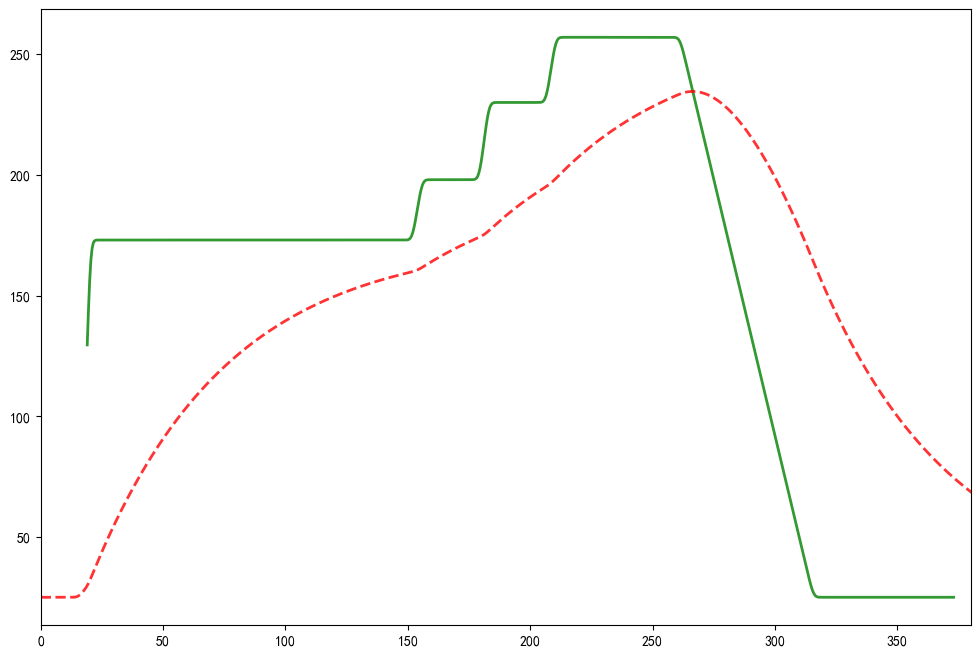

In [437]:
# 绘制实验数据与拟合数据的对比图
plt.figure(figsize=(12, 8))

# 计算各温区进入时间点
speed = 78  # cm/min，传送带速度
# 计算并绘制温区温度曲线
zone_temps = [173, 198, 230, 257]  # 温区设定温度

# 计算温区温度曲线
zone_temp_curve = []
for t in exp_time:
    position = calculate_position(t, speed)  # 根据时间计算位置
    zone_temp = get_zone_temp_smooth(position, zone_temps)  # 获取该位置的温区温度
    zone_temp_curve.append(zone_temp)

# 绘制温区温度曲线
plt.plot(exp_time, zone_temp_curve, 'g-', linewidth=2, label='温区设定温度', alpha=0.8)

# 绘制拟合数据
plt.plot(time2, fit_tmp2, 'r--', linewidth=2, label='模型拟合', alpha=0.8)
#plt.ylim(200, 250)
plt.xlim(0, 380)


In [439]:
# 最简单的方法
pd.DataFrame({
    'Time': time2,
    'Temperature': fit_tmp2
}).to_excel('model_fit_data.xlsx', index=False)

print(f"已保存 {len(time2)} 个数据点到 model_fit_data.xlsx")

已保存 800 个数据点到 model_fit_data.xlsx


In [445]:
tmp = get_zone_temp_smooth(304, [173, 198, 230, 257])
tmp

257.0